# Project GitHub: https://github.com/landname/AIT_736_final_project

In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
try:
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
    print("Loaded MNIST from keras.")
except Exception as e:
    print("Keras download failed.")
    print(e)

    path = "mnist.npz"

    if not os.path.exists(path):
        raise FileNotFoundError(
            "mnist.npz not found. Please place mnist.npz in the same directory."
        )

    data = np.load(path)
    X_train_raw = data["x_train"]
    y_train_raw = data["y_train"]
    X_test_raw = data["x_test"]
    y_test_raw = data["y_test"]

    print("Loaded MNIST from local mnist.npz.")

print("Training data shape:", X_train_raw.shape)
print("Training labels shape:", y_train_raw.shape)
print("Test data shape:", X_test_raw.shape)
print("Test labels shape:", y_test_raw.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded MNIST from keras.
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


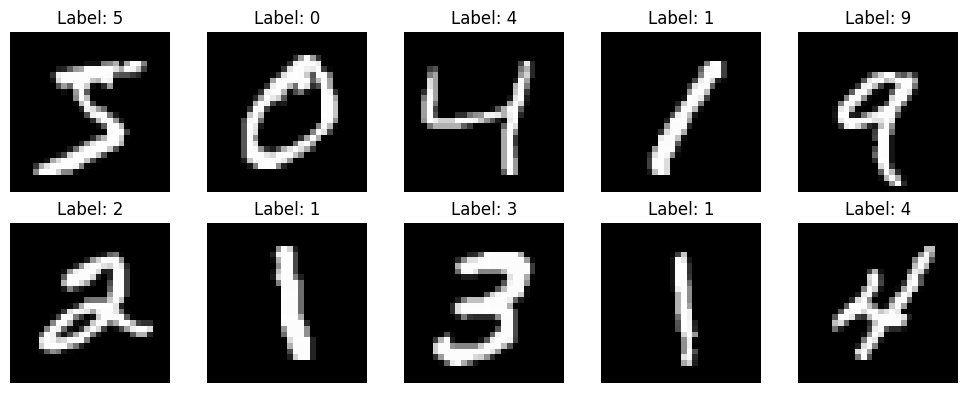

In [3]:

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(f"Label: {y_train_raw[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

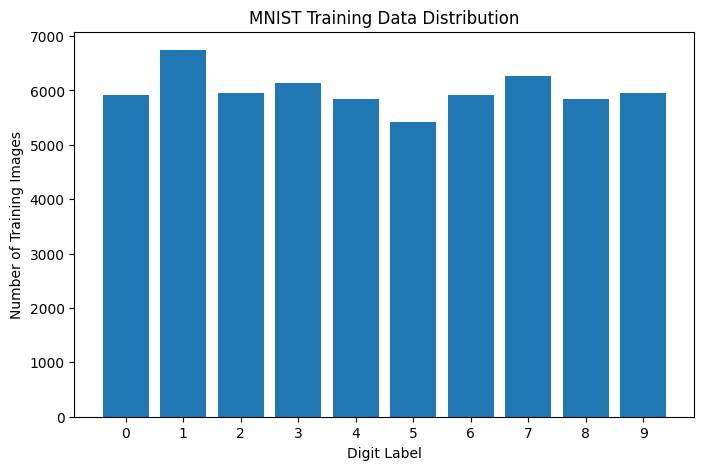

,digit,count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


In [4]:
unique, counts = np.unique(y_train_raw, return_counts=True)

plt.figure(figsize=(8, 5))
plt.bar(unique, counts)
plt.xlabel("Digit Label")
plt.ylabel("Number of Training Images")
plt.title("MNIST Training Data Distribution")
plt.xticks(unique)
plt.show()

class_dist = pd.DataFrame({
    "digit": unique,
    "count": counts
})

display(class_dist)

In [5]:
X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

y_train_cat = to_categorical(y_train_raw, 10)
y_test_cat = to_categorical(y_test_raw, 10)

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)
print("Flat train shape:", X_train_flat.shape)
print("Flat test shape:", X_test_flat.shape)
print("One-hot label shape:", y_train_cat.shape)

CNN train shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)
Flat train shape: (60000, 784)
Flat test shape: (10000, 784)
One-hot label shape: (60000, 10)


In [6]:
results = []

def add_result(model_name, y_true, y_pred, training_time=None, inference_time=None):
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "model": model_name,
        "accuracy": acc,
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1,
        "training_time_sec": training_time,
        "inference_time_sec": inference_time
    })

    print(f"\n{model_name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Weighted Precision: {precision:.4f}")
    print(f"Weighted Recall: {recall:.4f}")
    print(f"Weighted F1: {f1:.4f}")


def plot_history(history, title_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix}: Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix}: Loss")
    plt.legend()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
    disp.plot(cmap="Blues", values_format="d")
    plt.title(title)
    plt.show()


def show_prediction_examples(X_images, y_true, y_pred, correct=True, n=10):
    if correct:
        indices = np.where(y_true == y_pred)[0]
        title = "Correct Predictions"
    else:
        indices = np.where(y_true != y_pred)[0]
        title = "Incorrect Predictions"

    if len(indices) == 0:
        print("No examples found.")
        return

    selected = indices[:n]

    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(selected):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_images[idx].reshape(28, 28), cmap="gray")
        plt.title(f"True: {y_true[idx]}, Pred: {y_pred[idx]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def get_model_size_mb(file_path):
    size_mb = os.path.getsize(file_path) / (1024 * 1024)
    return size_mb


Logistic Regression Baseline
Accuracy: 0.9264
Weighted Precision: 0.9262
Weighted Recall: 0.9264
Weighted F1: 0.9262

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.92      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.94      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



<Figure size 800x800 with 0 Axes>

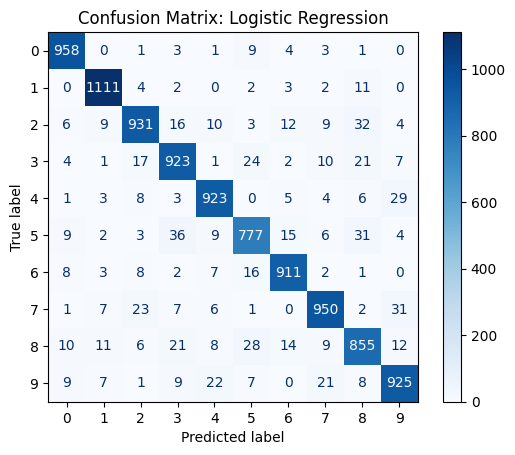

In [7]:
start_train = time.time()

logreg = LogisticRegression(
    max_iter=300,
    solver="lbfgs"
)

logreg.fit(X_train_flat, y_train_raw)

end_train = time.time()
logreg_training_time = end_train - start_train

start_pred = time.time()
logreg_pred = logreg.predict(X_test_flat)
end_pred = time.time()
logreg_inference_time = end_pred - start_pred

add_result(
    model_name="Logistic Regression Baseline",
    y_true=y_test_raw,
    y_pred=logreg_pred,
    training_time=logreg_training_time,
    inference_time=logreg_inference_time
)

print("\nClassification Report: Logistic Regression")
print(classification_report(y_test_raw, logreg_pred))

plot_confusion_matrix(
    y_true=y_test_raw,
    y_pred=logreg_pred,
    title="Confusion Matrix: Logistic Regression"
)


Random Forest Baseline
Accuracy: 0.9704
Weighted Precision: 0.9704
Weighted Recall: 0.9704
Weighted F1: 0.9704

Classification Report: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Figure size 800x800 with 0 Axes>

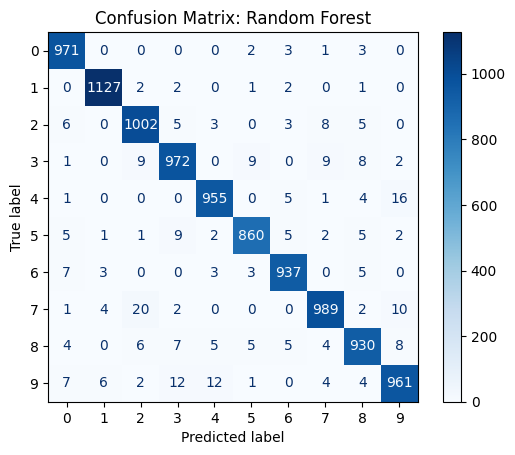

In [8]:
start_train = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)

rf.fit(X_train_flat, y_train_raw)

end_train = time.time()
rf_training_time = end_train - start_train

start_pred = time.time()
rf_pred = rf.predict(X_test_flat)
end_pred = time.time()
rf_inference_time = end_pred - start_pred

add_result(
    model_name="Random Forest Baseline",
    y_true=y_test_raw,
    y_pred=rf_pred,
    training_time=rf_training_time,
    inference_time=rf_inference_time
)

print("\nClassification Report: Random Forest")
print(classification_report(y_test_raw, rf_pred))

plot_confusion_matrix(
    y_true=y_test_raw,
    y_pred=rf_pred,
    title="Confusion Matrix: Random Forest"
)

In [9]:
def build_basic_cnn(learning_rate=0.001, dropout_rate=0.3):
    model = Sequential([
        Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(28, 28, 1)
        ),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(
            64,
            kernel_size=(3, 3),
            activation="relu"
        ),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


basic_cnn = build_basic_cnn(
    learning_rate=0.001,
    dropout_rate=0.3
)

basic_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 97ms/step - accuracy: 0.9235 - loss: 0.2539 - val_accuracy: 0.9840 - val_loss: 0.0588
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9768 - loss: 0.0770 - val_accuracy: 0.9862 - val_loss: 0.0462
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 94ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9872 - val_loss: 0.0425
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9869 - loss: 0.0427 - val_accuracy: 0.9905 - val_loss: 0.0351
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9887 - loss: 0.0364 - val_accuracy: 0.9902 - val_loss: 0.0354


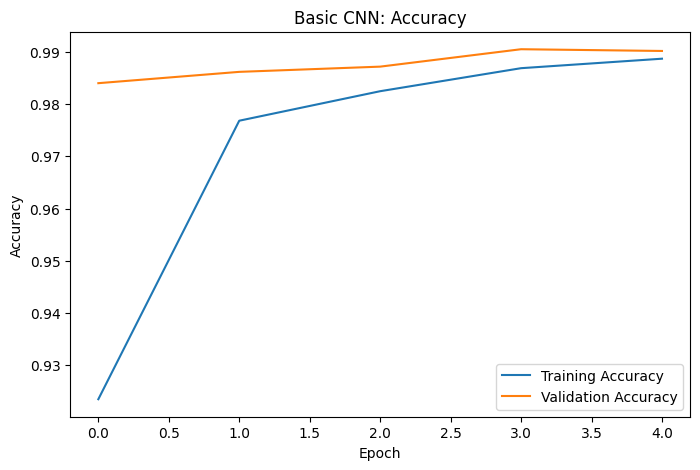

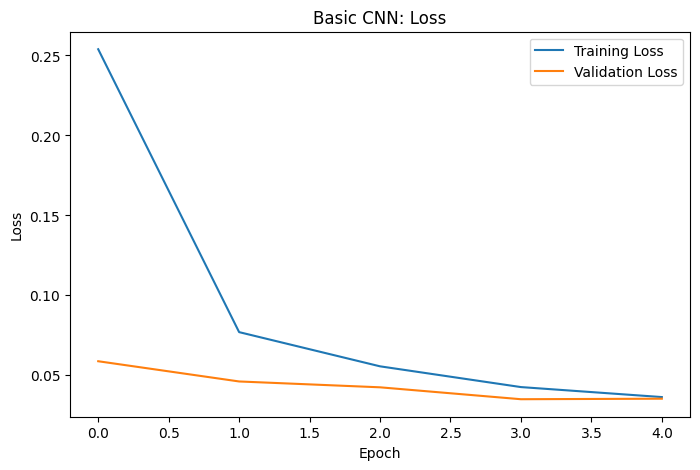

In [10]:
start_train = time.time()

history_basic = basic_cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

end_train = time.time()
basic_cnn_training_time = end_train - start_train

plot_history(history_basic, "Basic CNN")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Basic CNN
Accuracy: 0.9906
Weighted Precision: 0.9906
Weighted Recall: 0.9906
Weighted F1: 0.9906

Test Loss: 0.0283
Test Accuracy: 0.9906

Classification Report: Basic CNN
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      1.00      0.99       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



<Figure size 800x800 with 0 Axes>

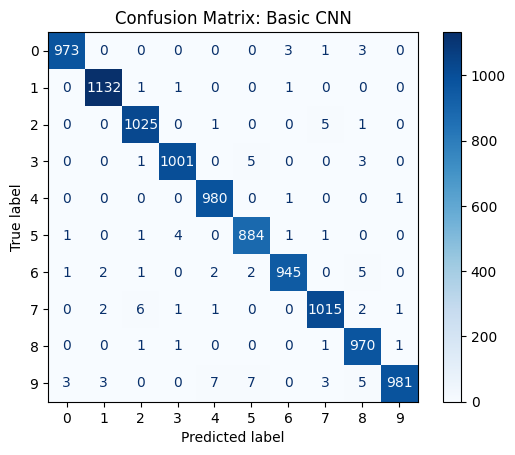

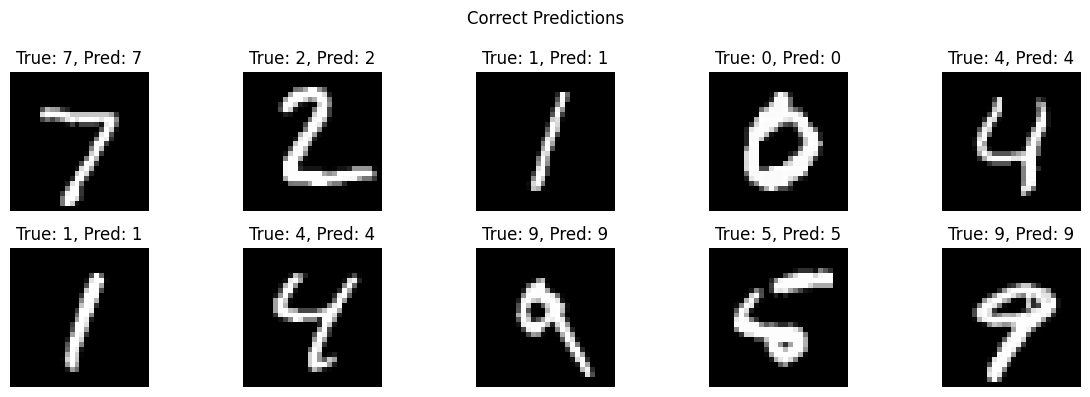

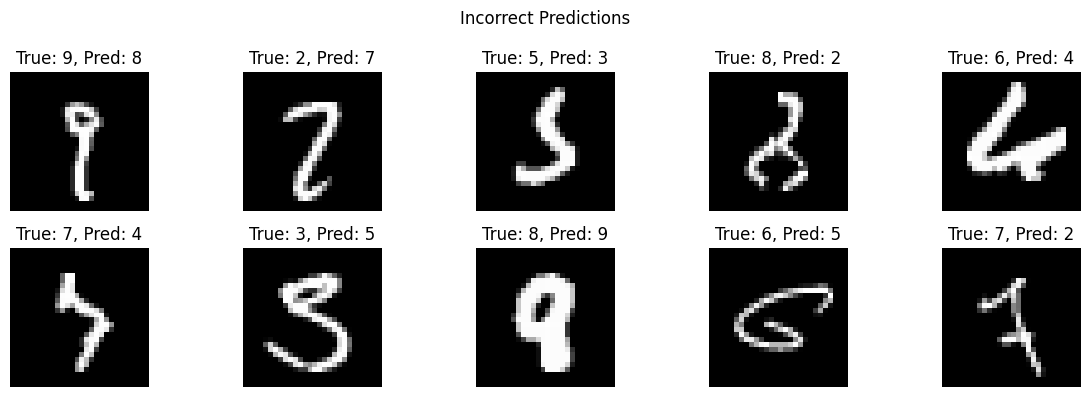

In [11]:
test_loss, test_acc = basic_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)

start_pred = time.time()
basic_cnn_prob = basic_cnn.predict(X_test_cnn)
end_pred = time.time()

basic_cnn_pred = np.argmax(basic_cnn_prob, axis=1)
basic_cnn_inference_time = end_pred - start_pred

add_result(
    model_name="Basic CNN",
    y_true=y_test_raw,
    y_pred=basic_cnn_pred,
    training_time=basic_cnn_training_time,
    inference_time=basic_cnn_inference_time
)

print("\nTest Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

print("\nClassification Report: Basic CNN")
print(classification_report(y_test_raw, basic_cnn_pred))

plot_confusion_matrix(
    y_true=y_test_raw,
    y_pred=basic_cnn_pred,
    title="Confusion Matrix: Basic CNN"
)

show_prediction_examples(
    X_images=X_test_cnn,
    y_true=y_test_raw,
    y_pred=basic_cnn_pred,
    correct=True,
    n=10
)

show_prediction_examples(
    X_images=X_test_cnn,
    y_true=y_test_raw,
    y_pred=basic_cnn_pred,
    correct=False,
    n=10
)

In [12]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

datagen.fit(X_train_cnn)

aug_cnn = build_basic_cnn(
    learning_rate=0.001,
    dropout_rate=0.3
)

aug_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 142ms/step - accuracy: 0.8532 - loss: 0.4623 - val_accuracy: 0.9784 - val_loss: 0.0639
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - accuracy: 0.9481 - loss: 0.1695 - val_accuracy: 0.9849 - val_loss: 0.0461
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.9629 - loss: 0.1217 - val_accuracy: 0.9901 - val_loss: 0.0299
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - accuracy: 0.9697 - loss: 0.1003 - val_accuracy: 0.9916 - val_loss: 0.0255
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 131ms/step - accuracy: 0.9726 - loss: 0.0893 - val_accuracy: 0.9921 - val_loss: 0.0273


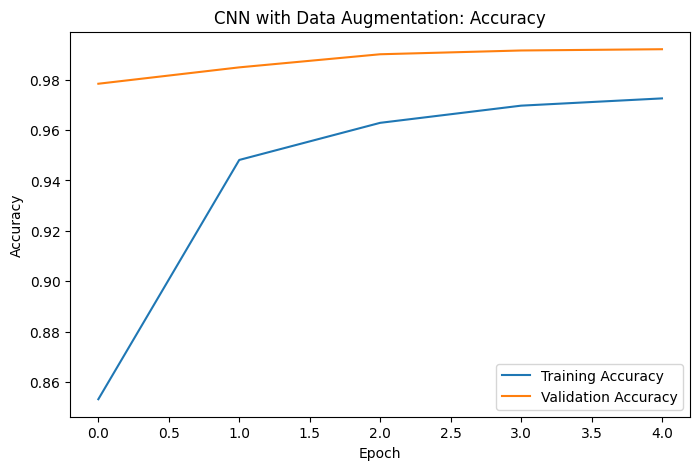

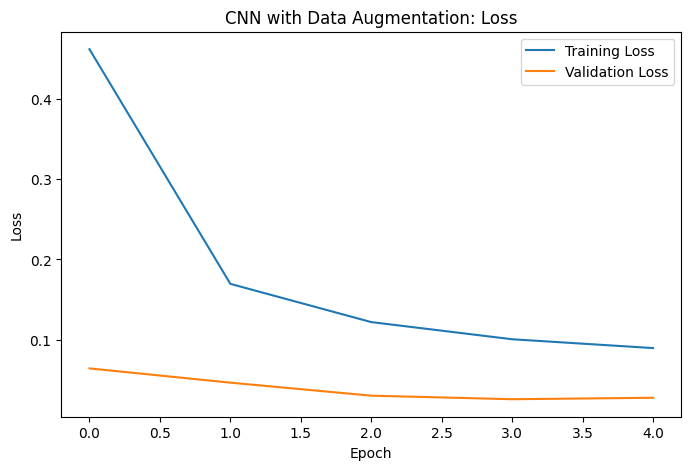

In [13]:
start_train = time.time()

history_aug = aug_cnn.fit(
    datagen.flow(X_train_cnn, y_train_cat, batch_size=128),
    epochs=5,
    validation_data=(X_test_cnn, y_test_cat),
    verbose=1
)

end_train = time.time()
aug_cnn_training_time = end_train - start_train

plot_history(history_aug, "CNN with Data Augmentation")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

CNN with Data Augmentation
Accuracy: 0.9921
Weighted Precision: 0.9921
Weighted Recall: 0.9921
Weighted F1: 0.9921

Test Loss: 0.0273
Test Accuracy: 0.9921

Classification Report: CNN with Data Augmentation
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99    

<Figure size 800x800 with 0 Axes>

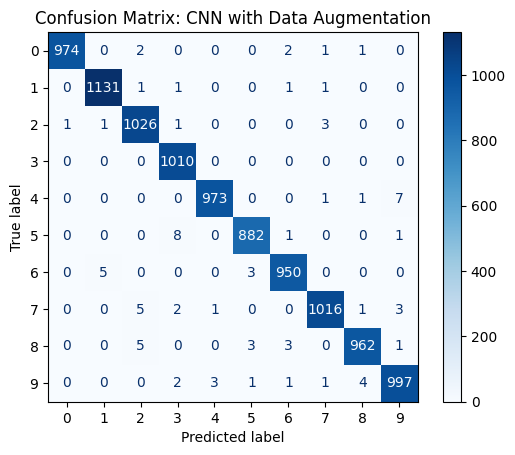

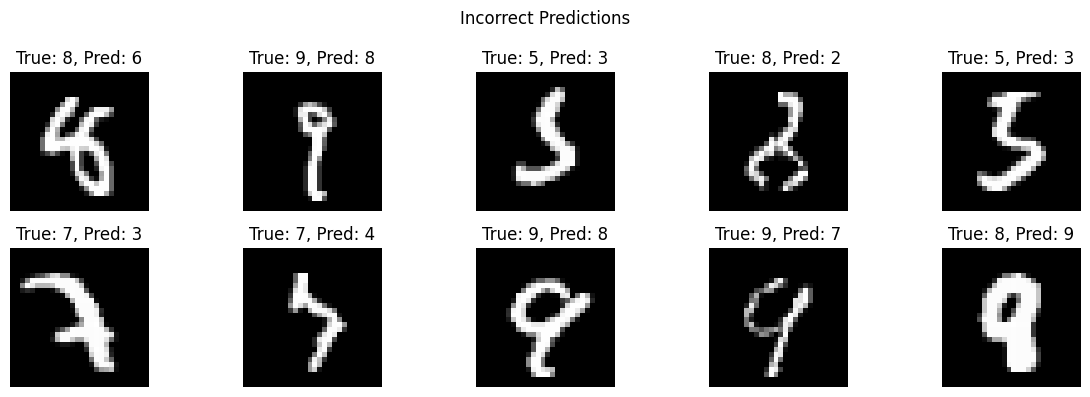

In [14]:
test_loss_aug, test_acc_aug = aug_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)

start_pred = time.time()
aug_cnn_prob = aug_cnn.predict(X_test_cnn)
end_pred = time.time()

aug_cnn_pred = np.argmax(aug_cnn_prob, axis=1)
aug_cnn_inference_time = end_pred - start_pred

add_result(
    model_name="CNN with Data Augmentation",
    y_true=y_test_raw,
    y_pred=aug_cnn_pred,
    training_time=aug_cnn_training_time,
    inference_time=aug_cnn_inference_time
)

print("\nTest Loss:", round(test_loss_aug, 4))
print("Test Accuracy:", round(test_acc_aug, 4))

print("\nClassification Report: CNN with Data Augmentation")
print(classification_report(y_test_raw, aug_cnn_pred))

plot_confusion_matrix(
    y_true=y_test_raw,
    y_pred=aug_cnn_pred,
    title="Confusion Matrix: CNN with Data Augmentation"
)

show_prediction_examples(
    X_images=X_test_cnn,
    y_true=y_test_raw,
    y_pred=aug_cnn_pred,
    correct=False,
    n=10
)

,Final Model,Test Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time (sec),Inference Time (sec)
0,CNN with Data Augmentation,0.0273,0.9921,0.9921,0.9921,0.9921,315.1981,2.6672


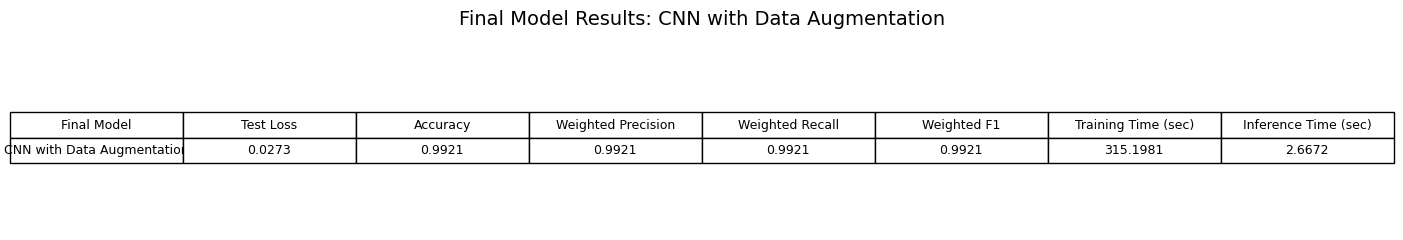

Saved final result table as final_aug_cnn_exports/cnn_with_data_augmentation_final_result_table.png


,precision,recall,f1-score,support
0,0.9990,0.9939,0.9964,980.0000
1,0.9947,0.9965,0.9956,1135.0000
2,0.9875,0.9942,0.9908,1032.0000
3,0.9863,1.0000,0.9931,1010.0000
4,0.9959,0.9908,0.9934,982.0000
5,0.9921,0.9888,0.9905,892.0000
6,0.9916,0.9916,0.9916,958.0000
7,0.9932,0.9883,0.9907,1028.0000
8,0.9928,0.9877,0.9902,974.0000
9,0.9881,0.9881,0.9881,1009.0000


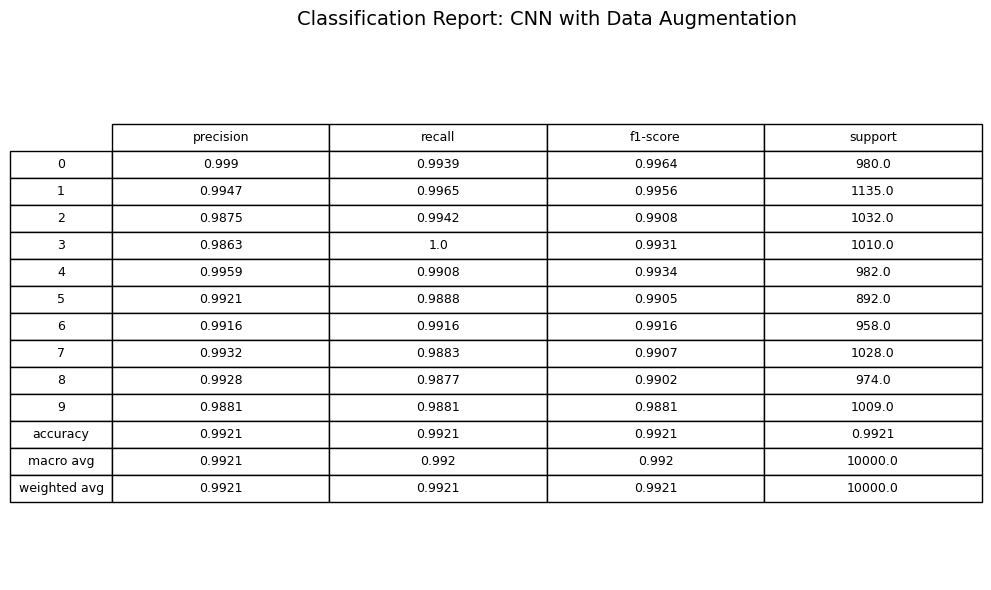

Saved classification report as final_aug_cnn_exports/cnn_with_data_augmentation_final_classification_report.png


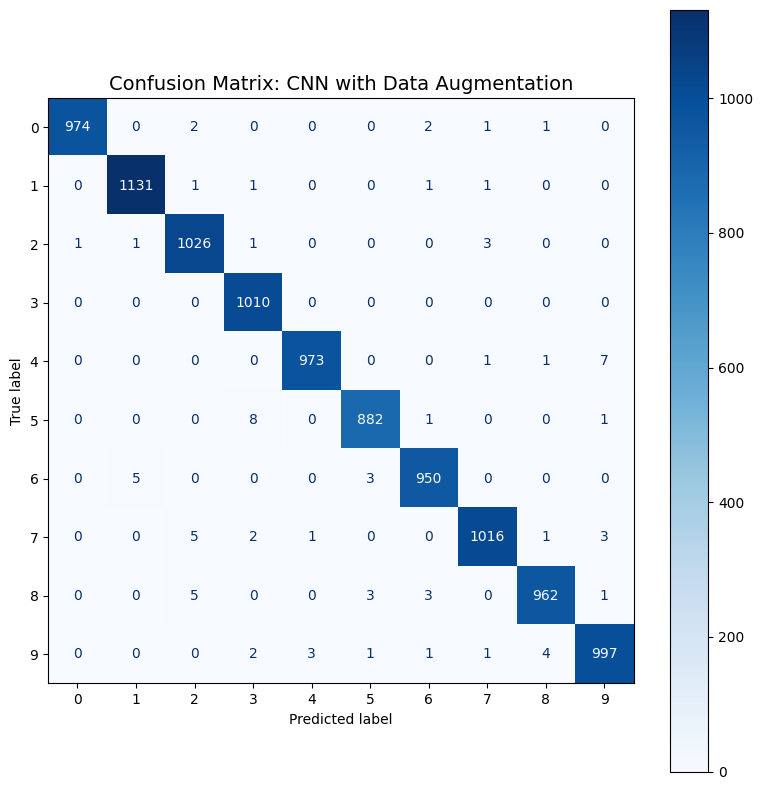

Saved confusion matrix as final_aug_cnn_exports/cnn_with_data_augmentation_final_confusion_matrix.png


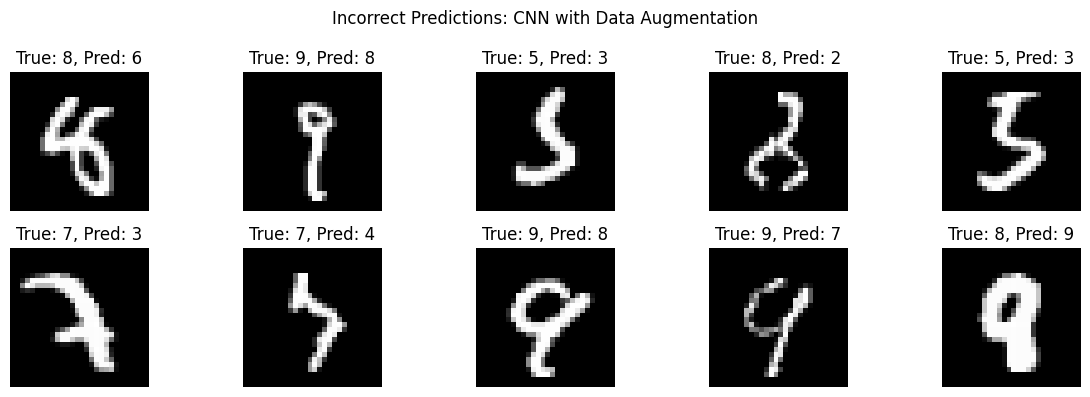

Saved incorrect prediction image as final_aug_cnn_exports/cnn_with_data_augmentation_final_incorrect_predictions.png


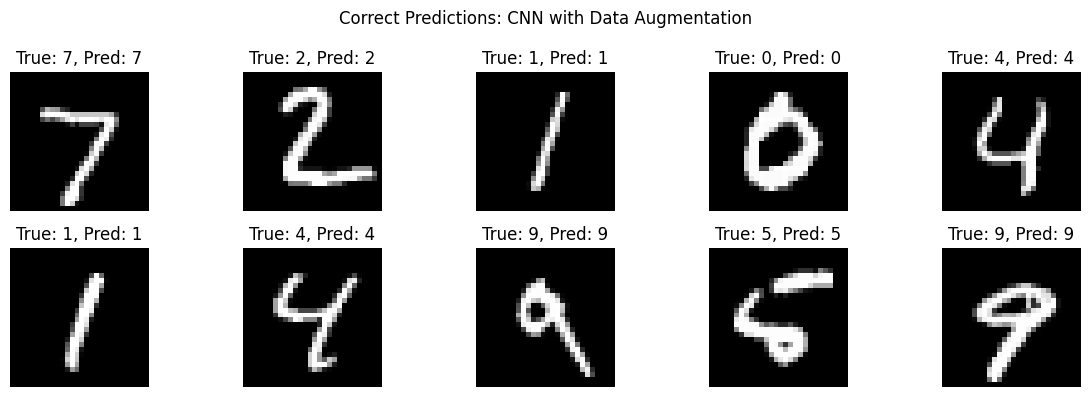

Saved correct prediction image as final_aug_cnn_exports/cnn_with_data_augmentation_final_correct_predictions.png
Saved final model as final_aug_cnn_exports/cnn_with_data_augmentation_final.h5
Saved final model as final_aug_cnn_exports/cnn_with_data_augmentation_final.keras


Saved model summary as final_aug_cnn_exports/cnn_with_data_augmentation_final_model_summary.txt
Saved artifact at '/tmp/tmpmvy1mca3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136727935014608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935015184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935021520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935014032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935022288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935024208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935019408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727935023440: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved TensorFlow Lite model as final_aug_cnn_exports/cnn_wi

,File,Format,Size MB
0,cnn_with_data_augmentation_final.h5,H5,2.6143
1,cnn_with_data_augmentation_final.keras,Keras,2.6127
2,cnn_with_data_augmentation_final.tflite,TFLite,0.8624


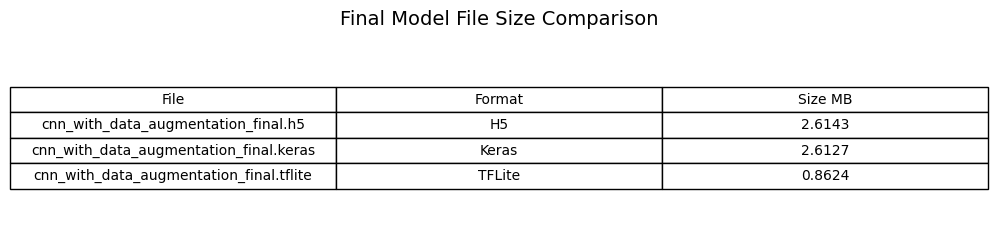

Saved file size table as final_aug_cnn_exports/cnn_with_data_augmentation_final_file_size_table.png
Saved final metrics CSV as final_aug_cnn_exports/cnn_with_data_augmentation_final_metrics.csv
Saved classification report CSV as final_aug_cnn_exports/cnn_with_data_augmentation_final_classification_report.csv
Saved file size CSV as final_aug_cnn_exports/cnn_with_data_augmentation_final_file_sizes.csv
FINAL MODEL SELECTED
Final Model: CNN with Data Augmentation
Test Loss: 0.0273
Test Accuracy: 0.9921
Weighted Precision: 0.9921
Weighted Recall: 0.9921
Weighted F1-score: 0.9921
Training Time: 315.1981 seconds
Inference Time: 2.6672 seconds

Exported files are saved in:
final_aug_cnn_exports


In [15]:
# ============================================================
# Final Model Export: CNN with Data Augmentation
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1. Create export folder
# -----------------------------
export_dir = "final_aug_cnn_exports"
os.makedirs(export_dir, exist_ok=True)

final_model_name = "cnn_with_data_augmentation_final"


# -----------------------------
# 2. Calculate final metrics
# -----------------------------
final_accuracy = accuracy_score(y_test_raw, aug_cnn_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_raw,
    aug_cnn_pred,
    average="weighted",
    zero_division=0
)

final_result_df = pd.DataFrame([{
    "Final Model": "CNN with Data Augmentation",
    "Test Loss": test_loss_aug,
    "Accuracy": final_accuracy,
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Weighted F1": f1,
    "Training Time (sec)": aug_cnn_training_time,
    "Inference Time (sec)": aug_cnn_inference_time
}])

final_result_display = final_result_df.copy()

for col in final_result_display.columns:
    if col != "Final Model":
        final_result_display[col] = final_result_display[col].round(4)

display(final_result_display)


# -----------------------------
# 3. Save final result table image
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis("off")

table = ax.table(
    cellText=final_result_display.values,
    colLabels=final_result_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

plt.title("Final Model Results: CNN with Data Augmentation", fontsize=14, pad=15)
plt.tight_layout()

result_table_path = os.path.join(export_dir, final_model_name + "_result_table.png")

plt.savefig(
    result_table_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved final result table as {result_table_path}")


# -----------------------------
# 4. Save classification report image
# -----------------------------
report_dict = classification_report(
    y_test_raw,
    aug_cnn_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.round(4)

display(report_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.4)

plt.title("Classification Report: CNN with Data Augmentation", fontsize=14, pad=15)
plt.tight_layout()

report_path = os.path.join(export_dir, final_model_name + "_classification_report.png")

plt.savefig(
    report_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved classification report as {report_path}")


# -----------------------------
# 5. Save confusion matrix image
# -----------------------------
cm = confusion_matrix(y_test_raw, aug_cnn_pred)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix: CNN with Data Augmentation", fontsize=14)
plt.tight_layout()

cm_path = os.path.join(export_dir, final_model_name + "_confusion_matrix.png")

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved confusion matrix as {cm_path}")


# -----------------------------
# 6. Save incorrect prediction examples image
# -----------------------------
wrong_indices = np.where(y_test_raw != aug_cnn_pred)[0]

if len(wrong_indices) > 0:
    selected_wrong = wrong_indices[:10]

    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(selected_wrong):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test_cnn[idx].reshape(28, 28), cmap="gray")
        plt.title(f"True: {y_test_raw[idx]}, Pred: {aug_cnn_pred[idx]}")
        plt.axis("off")

    plt.suptitle("Incorrect Predictions: CNN with Data Augmentation")
    plt.tight_layout()

    wrong_path = os.path.join(export_dir, final_model_name + "_incorrect_predictions.png")

    plt.savefig(
        wrong_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved incorrect prediction image as {wrong_path}")
else:
    print("No incorrect predictions found.")


# -----------------------------
# 7. Save correct prediction examples image
# -----------------------------
correct_indices = np.where(y_test_raw == aug_cnn_pred)[0]

if len(correct_indices) > 0:
    selected_correct = correct_indices[:10]

    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(selected_correct):
        plt.subplot(2, 5, i + 1)
        plt.imshow(X_test_cnn[idx].reshape(28, 28), cmap="gray")
        plt.title(f"True: {y_test_raw[idx]}, Pred: {aug_cnn_pred[idx]}")
        plt.axis("off")

    plt.suptitle("Correct Predictions: CNN with Data Augmentation")
    plt.tight_layout()

    correct_path = os.path.join(export_dir, final_model_name + "_correct_predictions.png")

    plt.savefig(
        correct_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved correct prediction image as {correct_path}")
else:
    print("No correct predictions found.")


# -----------------------------
# 8. Save final model as .h5 and .keras
# -----------------------------
h5_path = os.path.join(export_dir, final_model_name + ".h5")
keras_path = os.path.join(export_dir, final_model_name + ".keras")

aug_cnn.save(h5_path)
aug_cnn.save(keras_path)

print(f"Saved final model as {h5_path}")
print(f"Saved final model as {keras_path}")


# -----------------------------
# 9. Save model summary as text file
# -----------------------------
summary_path = os.path.join(export_dir, final_model_name + "_model_summary.txt")

with open(summary_path, "w") as f:
    aug_cnn.summary(print_fn=lambda x: f.write(x + "\n"))

print(f"Saved model summary as {summary_path}")


# -----------------------------
# 10. Convert final model to TensorFlow Lite
# -----------------------------
converter = tf.lite.TFLiteConverter.from_keras_model(aug_cnn)
tflite_model = converter.convert()

tflite_path = os.path.join(export_dir, final_model_name + ".tflite")

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"Saved TensorFlow Lite model as {tflite_path}")


# -----------------------------
# 11. Compare model file sizes
# -----------------------------
def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 * 1024)

h5_size = get_file_size_mb(h5_path)
keras_size = get_file_size_mb(keras_path)
tflite_size = get_file_size_mb(tflite_path)

size_df = pd.DataFrame([
    {"File": os.path.basename(h5_path), "Format": "H5", "Size MB": h5_size},
    {"File": os.path.basename(keras_path), "Format": "Keras", "Size MB": keras_size},
    {"File": os.path.basename(tflite_path), "Format": "TFLite", "Size MB": tflite_size}
])

size_df["Size MB"] = size_df["Size MB"].round(4)

display(size_df)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")

table = ax.table(
    cellText=size_df.values,
    colLabels=size_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)

plt.title("Final Model File Size Comparison", fontsize=14, pad=15)
plt.tight_layout()

size_table_path = os.path.join(export_dir, final_model_name + "_file_size_table.png")

plt.savefig(
    size_table_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved file size table as {size_table_path}")


# -----------------------------
# 12. Save final metrics as CSV
# -----------------------------
metrics_csv_path = os.path.join(export_dir, final_model_name + "_metrics.csv")
final_result_df.to_csv(metrics_csv_path, index=False)

report_csv_path = os.path.join(export_dir, final_model_name + "_classification_report.csv")
report_df.to_csv(report_csv_path)

size_csv_path = os.path.join(export_dir, final_model_name + "_file_sizes.csv")
size_df.to_csv(size_csv_path, index=False)

print(f"Saved final metrics CSV as {metrics_csv_path}")
print(f"Saved classification report CSV as {report_csv_path}")
print(f"Saved file size CSV as {size_csv_path}")


# -----------------------------
# 13. Final print summary
# -----------------------------
print("=" * 70)
print("FINAL MODEL SELECTED")
print("=" * 70)

print("Final Model: CNN with Data Augmentation")
print(f"Test Loss: {test_loss_aug:.4f}")
print(f"Test Accuracy: {test_acc_aug:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}")
print(f"Training Time: {aug_cnn_training_time:.4f} seconds")
print(f"Inference Time: {aug_cnn_inference_time:.4f} seconds")

print("\nExported files are saved in:")
print(export_dir)

In [16]:
def build_batchnorm_cnn(learning_rate=0.001, dropout_rate=0.3):
    model = Sequential([
        Conv2D(
            32,
            kernel_size=(3, 3),
            activation="relu",
            input_shape=(28, 28, 1)
        ),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(
            64,
            kernel_size=(3, 3),
            activation="relu"
        ),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(
            128,
            kernel_size=(3, 3),
            activation="relu"
        ),
        BatchNormalization(),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(dropout_rate),
        Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


bn_cnn = build_batchnorm_cnn(
    learning_rate=0.001,
    dropout_rate=0.3
)

bn_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 71s 160ms/step - accuracy: 0.9591 - loss: 0.1314 - val_accuracy: 0.8128 - val_loss: 0.6652
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 158ms/step - accuracy: 0.9849 - loss: 0.0475 - val_accuracy: 0.9897 - val_loss: 0.0372
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 159ms/step - accuracy: 0.9905 - loss: 0.0304 - val_accuracy: 0.9898 - val_loss: 0.0407
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 161ms/step - accuracy: 0.9925 - loss: 0.0227 - val_accuracy: 0.9885 - val_loss: 0.0434
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 160ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.9853 - val_loss: 0.0542


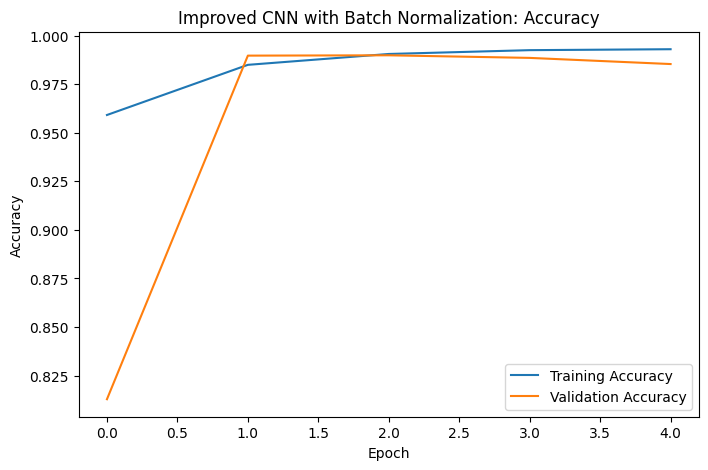

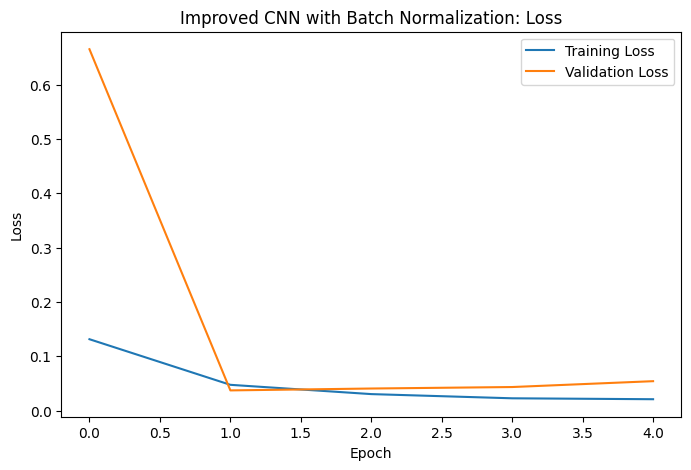

In [17]:
start_train = time.time()

history_bn = bn_cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

end_train = time.time()
bn_cnn_training_time = end_train - start_train

plot_history(history_bn, "Improved CNN with Batch Normalization")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Improved CNN with Batch Normalization
Accuracy: 0.9871
Weighted Precision: 0.9872
Weighted Recall: 0.9871
Weighted F1: 0.9871

Test Loss: 0.0418
Test Accuracy: 0.9871

Classification Report: Improved CNN
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.98      0.99      1135
           2       0.98      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.97      1.00      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     1

<Figure size 800x800 with 0 Axes>

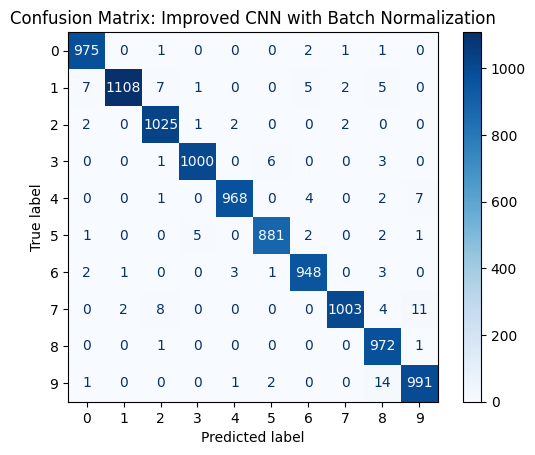

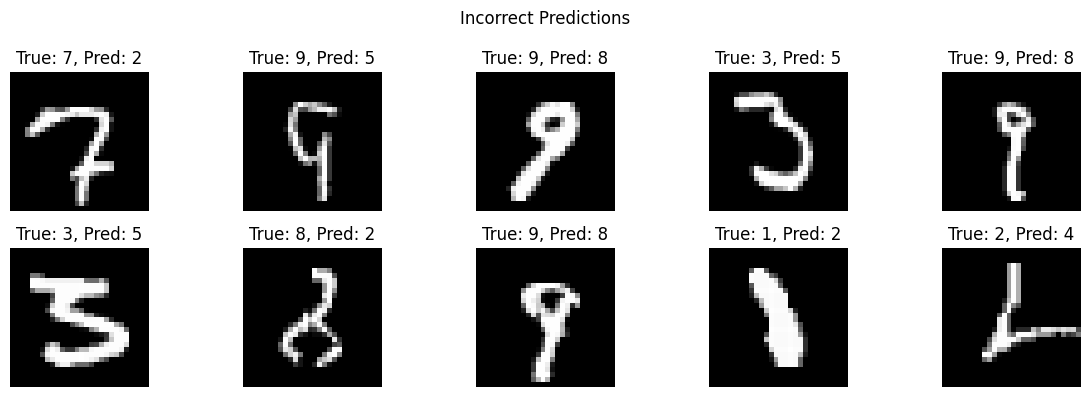

In [19]:
test_loss_bn, test_acc_bn = bn_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)

start_pred = time.time()
bn_cnn_prob = bn_cnn.predict(X_test_cnn)
end_pred = time.time()

bn_cnn_pred = np.argmax(bn_cnn_prob, axis=1)
bn_cnn_inference_time = end_pred - start_pred

add_result(
    model_name="Improved CNN with Batch Normalization",
    y_true=y_test_raw,
    y_pred=bn_cnn_pred,
    training_time=bn_cnn_training_time,
    inference_time=bn_cnn_inference_time
)

print("\nTest Loss:", round(test_loss_bn, 4))
print("Test Accuracy:", round(test_acc_bn, 4))

print("\nClassification Report: Improved CNN")
print(classification_report(y_test_raw, bn_cnn_pred))

plot_confusion_matrix(
    y_true=y_test_raw,
    y_pred=bn_cnn_pred,
    title="Confusion Matrix: Improved CNN with Batch Normalization"
)

show_prediction_examples(
    X_images=X_test_cnn,
    y_true=y_test_raw,
    y_pred=bn_cnn_pred,
    correct=False,
    n=10
)

In [20]:
tuning_results = []

learning_rates = [0.001, 0.0005]
dropout_rates = [0.3, 0.5]
batch_sizes = [128]

for lr in learning_rates:
    for dropout in dropout_rates:
        for batch_size in batch_sizes:

            print("=" * 60)
            print(f"Training CNN: lr={lr}, dropout={dropout}, batch_size={batch_size}")

            temp_model = build_basic_cnn(
                learning_rate=lr,
                dropout_rate=dropout
            )

            start_train = time.time()

            temp_history = temp_model.fit(
                X_train_cnn,
                y_train_cat,
                epochs=3,
                batch_size=batch_size,
                validation_split=0.1,
                verbose=1
            )

            end_train = time.time()
            training_time = end_train - start_train

            test_loss_temp, test_acc_temp = temp_model.evaluate(
                X_test_cnn,
                y_test_cat,
                verbose=0
            )

            tuning_results.append({
                "learning_rate": lr,
                "dropout_rate": dropout,
                "batch_size": batch_size,
                "epochs": 3,
                "test_loss": test_loss_temp,
                "test_accuracy": test_acc_temp,
                "training_time_sec": training_time
            })

tuning_df = pd.DataFrame(tuning_results)
tuning_df = tuning_df.sort_values(by="test_accuracy", ascending=False)

display(tuning_df)

Training CNN: lr=0.001, dropout=0.3, batch_size=128


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 101ms/step - accuracy: 0.9142 - loss: 0.2811 - val_accuracy: 0.9830 - val_loss: 0.0611
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9743 - loss: 0.0834 - val_accuracy: 0.9857 - val_loss: 0.0491
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.9824 - loss: 0.0575 - val_accuracy: 0.9903 - val_loss: 0.0403
Training CNN: lr=0.001, dropout=0.5, batch_size=128
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.9001 - loss: 0.3270 - val_accuracy: 0.9822 - val_loss: 0.0599
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9680 - loss: 0.1091 - val_accuracy: 0.9847 - val_loss: 0.0487
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - accuracy: 0.9746 - loss: 0.0840 - val_accuracy: 0.9895 - val_loss: 0.0388
Training CNN: lr=0.0005, dropout=0.3, batch_size=128
Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.8897 - loss: 0.3760 - val_accuracy: 0.9767 - val_l

,learning_rate,dropout_rate,batch_size,epochs,test_loss,test_accuracy,training_time_sec
1,0.0010,0.5,128,3,0.035420,0.9885,126.536106
0,0.0010,0.3,128,3,0.038707,0.9870,208.224627
2,0.0005,0.3,128,3,0.040444,0.9868,125.034799
3,0.0005,0.5,128,3,0.047212,0.9836,121.968633


In [21]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="accuracy", ascending=False)

display(results_df)

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_sec,inference_time_sec
3,CNN with Data Augmentation,0.9921,0.992117,0.9921,0.992100,315.198097,2.667206
2,Basic CNN,0.9906,0.990638,0.9906,0.990593,201.651596,5.187431
4,Improved CNN with Batch Normalization,0.9871,0.987223,0.9871,0.987107,384.147731,4.118690
1,Random Forest Baseline,0.9704,0.970396,0.9704,0.970372,43.850126,0.379557
0,Logistic Regression Baseline,0.9264,0.926195,0.9264,0.926227,116.085655,0.050779


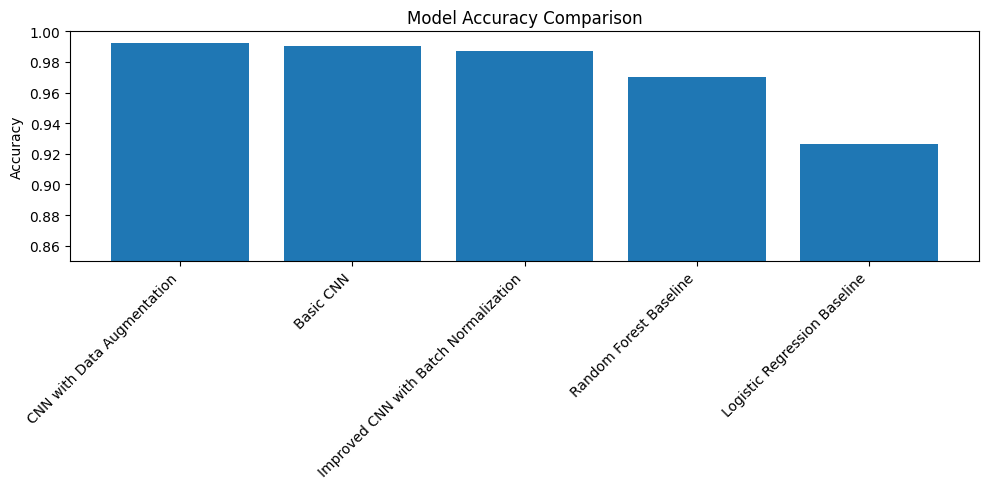

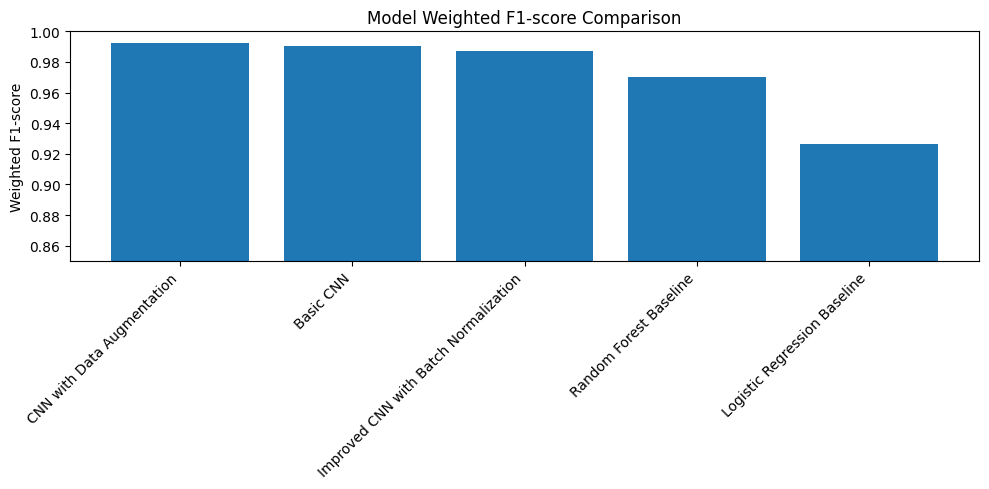

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["weighted_f1"])
plt.ylabel("Weighted F1-score")
plt.title("Model Weighted F1-score Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

In [23]:
best_model = bn_cnn
best_model_name = "mnist_best_cnn_model"

keras_model_path = best_model_name + ".h5"
best_model.save(keras_model_path)

model_size = get_model_size_mb(keras_model_path)

print(f"Saved Keras model to: {keras_model_path}")
print(f"Keras model size: {model_size:.2f} MB")

Saved Keras model to: mnist_best_cnn_model.h5
Keras model size: 2.84 MB


In [24]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()

tflite_path = best_model_name + ".tflite"

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

tflite_size = get_model_size_mb(tflite_path)

print(f"Saved TFLite model to: {tflite_path}")
print(f"TFLite model size: {tflite_size:.2f} MB")
print(f"Size reduction: {model_size - tflite_size:.2f} MB")

Saved artifact at '/tmp/tmppq8awx1z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_20')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136727929026320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929023632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929020560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929012304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929024784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929024976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929020944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929023056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929012496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136727929012

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Activation map shape: (1, 26, 26, 32)


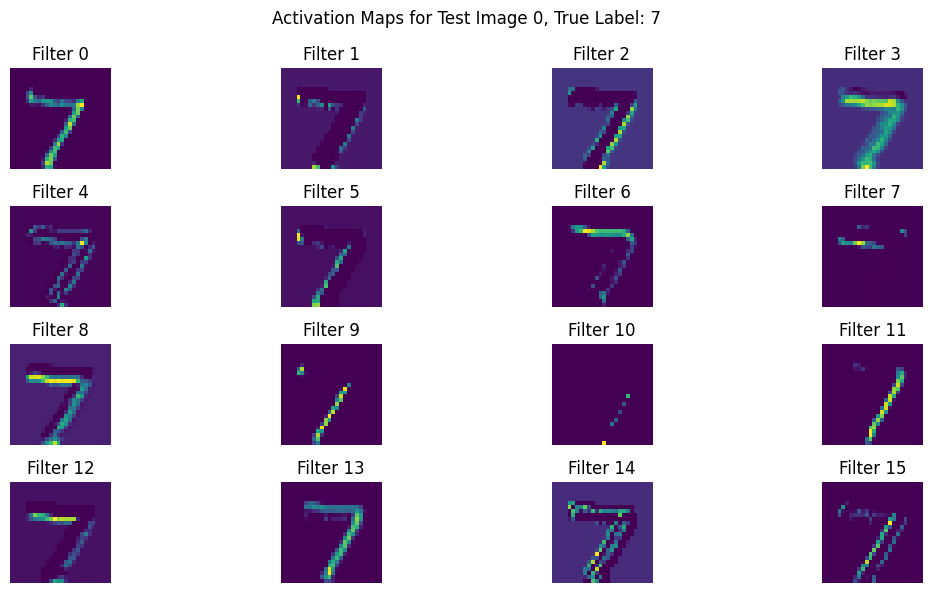

In [27]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D
import matplotlib.pyplot as plt
import numpy as np

# Make sure the model is built
_ = best_model.predict(X_test_cnn[:1])

conv_layer = None
for layer in best_model.layers:
    if isinstance(layer, Conv2D):
        conv_layer = layer
        break

if conv_layer is not None:
    activation_model = Model(
        inputs=best_model.inputs,
        outputs=conv_layer.output
    )

    sample_index = 0
    sample_image = X_test_cnn[sample_index:sample_index + 1]

    activations = activation_model.predict(sample_image)

    print("Activation map shape:", activations.shape)

    plt.figure(figsize=(12, 6))

    for i in range(min(16, activations.shape[-1])):
        plt.subplot(4, 4, i + 1)
        plt.imshow(activations[0, :, :, i], cmap="viridis")
        plt.axis("off")
        plt.title(f"Filter {i}")

    plt.suptitle(
        f"Activation Maps for Test Image {sample_index}, True Label: {y_test_raw[sample_index]}"
    )
    plt.tight_layout()
    plt.show()

else:
    print("No Conv2D layer found.")

In [28]:
print("=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print("\nModels compared:")
for model_name in results_df["model"]:
    print("-", model_name)

print("\nBest model based on accuracy:")
best_row = results_df.iloc[0]
print(best_row)

print("\nHyperparameter tuning results:")
display(tuning_df)

print("\nMain improvements added for rubric:")
print("1. Compared traditional ML baselines with CNN models.")
print("2. Added CNN with data augmentation.")
print("3. Added improved CNN architecture with Batch Normalization.")
print("4. Added simple hyperparameter tuning.")
print("5. Added classification report and confusion matrix.")
print("6. Added incorrect prediction analysis.")
print("7. Added inference speed measurement.")
print("8. Added model saving and TensorFlow Lite conversion.")
print("9. Added activation map visualization for interpretability.")

FINAL PROJECT SUMMARY

Models compared:
- CNN with Data Augmentation
- Basic CNN
- Improved CNN with Batch Normalization
- Random Forest Baseline
- Logistic Regression Baseline

Best model based on accuracy:
model                 CNN with Data Augmentation
accuracy                                  0.9921
weighted_precision                      0.992117
weighted_recall                           0.9921
weighted_f1                               0.9921
training_time_sec                     315.198097
inference_time_sec                      2.667206
Name: 3, dtype: object

Hyperparameter tuning results:


,learning_rate,dropout_rate,batch_size,epochs,test_loss,test_accuracy,training_time_sec
1,0.0010,0.5,128,3,0.035420,0.9885,126.536106
0,0.0010,0.3,128,3,0.038707,0.9870,208.224627
2,0.0005,0.3,128,3,0.040444,0.9868,125.034799
3,0.0005,0.5,128,3,0.047212,0.9836,121.968633



Main improvements added for rubric:
1. Compared traditional ML baselines with CNN models.
2. Added CNN with data augmentation.
3. Added improved CNN architecture with Batch Normalization.
4. Added simple hyperparameter tuning.
5. Added classification report and confusion matrix.
6. Added incorrect prediction analysis.
7. Added inference speed measurement.
8. Added model saving and TensorFlow Lite conversion.
9. Added activation map visualization for interpretability.


,Model,Test Loss,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Training Time (sec),Inference Time (sec)
0,Improved CNN with Batch Normalization,0.0418,0.9871,0.9872,0.9871,0.9871,384.1477,4.1187


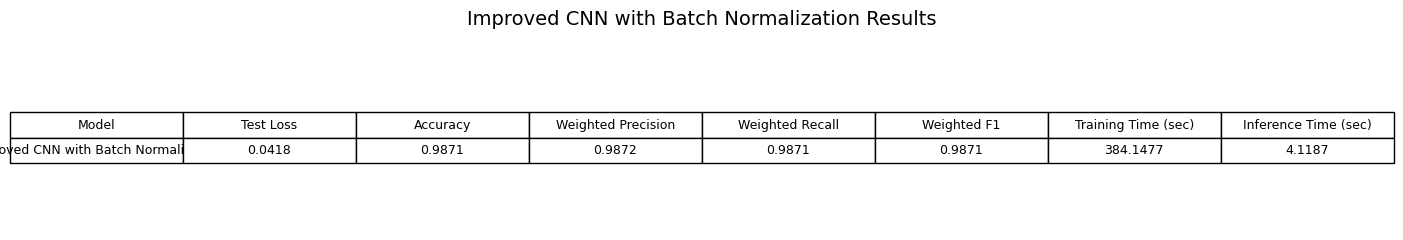

Saved image as bn_cnn_result_table.png


,precision,recall,f1-score,support
0,0.9868,0.9949,0.9909,980.0000
1,0.9973,0.9762,0.9866,1135.0000
2,0.9818,0.9932,0.9875,1032.0000
3,0.9930,0.9901,0.9916,1010.0000
4,0.9938,0.9857,0.9898,982.0000
5,0.9899,0.9877,0.9888,892.0000
6,0.9865,0.9896,0.9880,958.0000
7,0.9950,0.9757,0.9853,1028.0000
8,0.9662,0.9979,0.9818,974.0000
9,0.9802,0.9822,0.9812,1009.0000


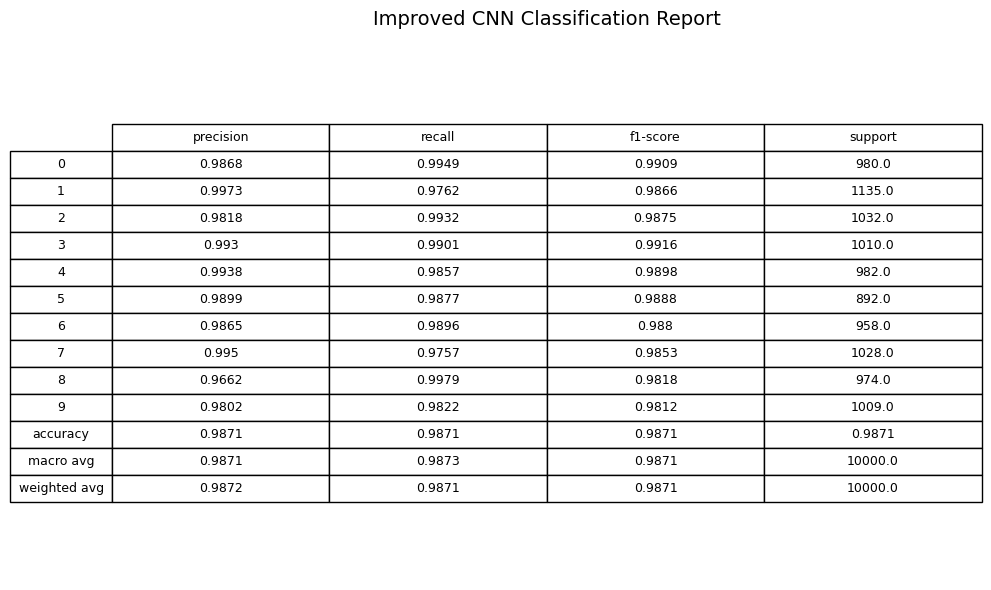

Saved image as bn_cnn_classification_report.png


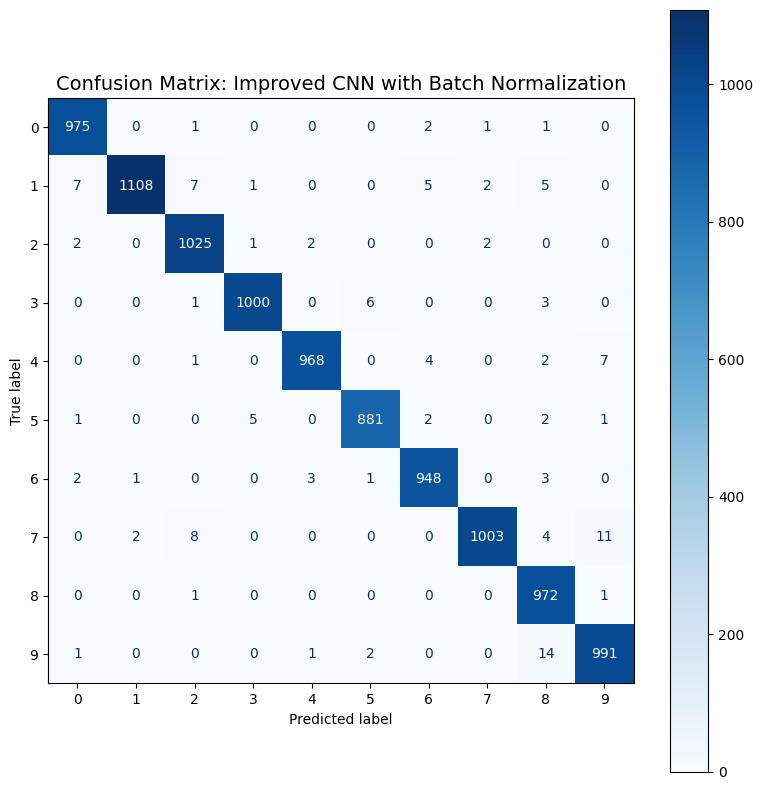

Saved image as bn_cnn_confusion_matrix.png
Saved model as bn_cnn_mnist_model.h5
Saved model as bn_cnn_mnist_model.keras


In [29]:
# ============================================================
# Export Improved CNN with Batch Normalization Results
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1. Result table image
# -----------------------------
bn_result_df = pd.DataFrame([{
    "Model": "Improved CNN with Batch Normalization",
    "Test Loss": test_loss_bn,
    "Accuracy": test_acc_bn,
    "Training Time (sec)": bn_cnn_training_time,
    "Inference Time (sec)": bn_cnn_inference_time
}])

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test_raw,
    bn_cnn_pred,
    average="weighted",
    zero_division=0
)

bn_result_df["Weighted Precision"] = precision
bn_result_df["Weighted Recall"] = recall
bn_result_df["Weighted F1"] = f1

bn_result_df = bn_result_df[
    [
        "Model",
        "Test Loss",
        "Accuracy",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1",
        "Training Time (sec)",
        "Inference Time (sec)"
    ]
]

bn_result_display = bn_result_df.copy()

for col in bn_result_display.columns:
    if col != "Model":
        bn_result_display[col] = bn_result_display[col].round(4)

display(bn_result_display)

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.axis("off")

table = ax.table(
    cellText=bn_result_display.values,
    colLabels=bn_result_display.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.6)

plt.title("Improved CNN with Batch Normalization Results", fontsize=14, pad=15)
plt.tight_layout()

plt.savefig(
    "bn_cnn_result_table.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved image as bn_cnn_result_table.png")


# -----------------------------
# 2. Classification report image
# -----------------------------
bn_report_dict = classification_report(
    y_test_raw,
    bn_cnn_pred,
    output_dict=True,
    zero_division=0
)

bn_report_df = pd.DataFrame(bn_report_dict).transpose()
bn_report_df = bn_report_df.round(4)

display(bn_report_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

table = ax.table(
    cellText=bn_report_df.values,
    rowLabels=bn_report_df.index,
    colLabels=bn_report_df.columns,
    cellLoc="center",
    rowLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.4)

plt.title("Improved CNN Classification Report", fontsize=14, pad=15)
plt.tight_layout()

plt.savefig(
    "bn_cnn_classification_report.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved image as bn_cnn_classification_report.png")


# -----------------------------
# 3. Confusion matrix image
# -----------------------------
bn_cm = confusion_matrix(y_test_raw, bn_cnn_pred)

fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=bn_cm,
    display_labels=np.arange(10)
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix: Improved CNN with Batch Normalization", fontsize=14)
plt.tight_layout()

plt.savefig(
    "bn_cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved image as bn_cnn_confusion_matrix.png")


# -----------------------------
# 4. Save model
# -----------------------------
bn_cnn.save("bn_cnn_mnist_model.h5")

print("Saved model as bn_cnn_mnist_model.h5")


# Optional: save as newer Keras format too
bn_cnn.save("bn_cnn_mnist_model.keras")

print("Saved model as bn_cnn_mnist_model.keras")